In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# import os
# os.kill(os.getpid(), 9) 

/kaggle/input/optimizados_2/tensorflow2/default/1/model_fold_3_NeuroVoz.h5
/kaggle/input/optimizados_2/tensorflow2/default/1/model_fold_1_NeuroVoz.h5
/kaggle/input/optimizados_2/tensorflow2/default/1/model_fold_2_NeuroVoz.h5
/kaggle/input/optimizados_2/tensorflow2/default/1/model_fold_4_NeuroVoz.h5
/kaggle/input/neurovoz-dataset/data/metadata/metadata_pd.csv
/kaggle/input/neurovoz-dataset/data/metadata/metadata_hc.csv
/kaggle/input/neurovoz-dataset/data/audio_features/audio_features.csv
/kaggle/input/neurovoz-dataset/data/audios/HC_DIABLO_0087.wav
/kaggle/input/neurovoz-dataset/data/audios/HC_E1_0105.wav
/kaggle/input/neurovoz-dataset/data/audios/PD_GANGA_0026.wav
/kaggle/input/neurovoz-dataset/data/audios/HC_PETACA_BLANCA_0063.wav
/kaggle/input/neurovoz-dataset/data/audios/HC_PERRO_0129.wav
/kaggle/input/neurovoz-dataset/data/audios/PD_I1_0006.wav
/kaggle/input/neurovoz-dataset/data/audios/HC_BURRO_0130.wav
/kaggle/input/neurovoz-dataset/data/audios/HC_I2_0053.wav
/kaggle/input/neurov

In [2]:
# Install librosa
!pip install librosa
!pip install keras-hub
!pip install keras-tuner
!pip install tf-keras-vis tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import zipfile
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                     AveragePooling2D, Reshape, Flatten, Dense, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import AUC
import numpy as np
import matplotlib.pyplot as plt

# For Grad-CAM and LRP, we use tf-keras-vis
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils import normalize

2025-06-02 21:57:06.559392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748901426.764140      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748901426.821480      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
import os
import re
import pandas as pd
import librosa


def cargar_etiquetas_audio(base_path: str):
    """
    Lee los archivos de metadatos y asigna etiquetas a los archivos de audio.

    Parámetros:
    ----------
    base_path : str
        Ruta base donde se encuentran los directorios 'metadata' y 'audios'.

    Retorna:
    -------
    rutas_audio : list of str
        Lista con las rutas completas de los archivos .wav.
    etiquetas : list of int
        Lista de etiquetas (0 para HC, 1 para PD) correspondiente a cada archivo de audio.
    """
    # Rutas a los archivos de metadatos
    dir_meta = os.path.join(base_path, 'metadata')
    path_hc = os.path.join(dir_meta, 'metadata_hc.csv')
    path_pd = os.path.join(dir_meta, 'metadata_pd.csv')

    # Leer metadatos y extraer IDs únicos
    df_hc = pd.read_csv(path_hc)
    df_pd = pd.read_csv(path_pd)
    ids_hc = set(df_hc['ID'].astype(str).unique())
    ids_pd = set(df_pd['ID'].astype(str).unique())
    print(f'ids_hc indexes: {ids_hc}')
    print(f'ids_pd indexes: {ids_pd}')

    # Directorio de audios
    dir_audios = os.path.join(base_path, 'audios')

    # Patrón para extraer ID de nombre de archivo
    # patron = re.compile(r'_[A-Z]1_(\d+)\.wav$', re.IGNORECASE)

    rutas_audio = []
    etiquetas = []
    tamaños = []

    # Recorrer archivos .wav

    tamaño_hc = 0
    tamaño_pd = 0
    for nombre in os.listdir(dir_audios):
        if nombre.lower().endswith('.wav'):
            ruta_completa = os.path.join(dir_audios, nombre)
            y, sr = librosa.load(ruta_completa)
            rutas_audio.append(y)
            tamaños.append(y.shape[0])
            # Extraer ID con regex
            
            
            # Asignar etiqueta: 0 si HC, 1 si PD
            if nombre[:2] == 'HC':
                etiquetas.append(0)
                tamaño_hc += 1
            elif nombre[:2] == 'PD':
                etiquetas.append(1)
                tamaño_pd += 1
            else:
                etiquetas.append(-1)
    print(tamaño_hc,tamaño_pd)
    return rutas_audio, np.array(etiquetas), tamaños

path = '/kaggle/input/neurovoz-dataset/data'
X, labels, tamaños= cargar_etiquetas_audio(path)

print(len(X), labels.shape, len(tamaños))
print(np.unique(labels))

ids_hc indexes: {'64', '75', '86', '73', '138', '49', '133', '116', '145', '128', '144', '134', '53', '122', '80', '132', '61', '63', '129', '51', '56', '142', '60', '120', '76', '105', '83', '72', '82', '87', '143', '118', '34', '62', '65', '45', '135', '74', '137', '139', '54', '85', '36', '121', '55', '136', '141', '52', '140', '71', '112', '48', '81', '130', '131'}
ids_pd indexes: {'67', '27', '15', '117', '42', '9', '66', '13', '4', '7', '43', '24', '78', '8', '79', '113', '115', '26', '16', '17', '19', '28', '32', '47', '30', '10', '21', '44', '18', '11', '20', '40', '22', '46', '12', '70', '33', '6', '41', '25', '29', '31', '39', '58', '37', '35', '111', '77', '108', '14', '23', '109', '38'}
1509 1467
2976 (2976,) 2976
[0 1]


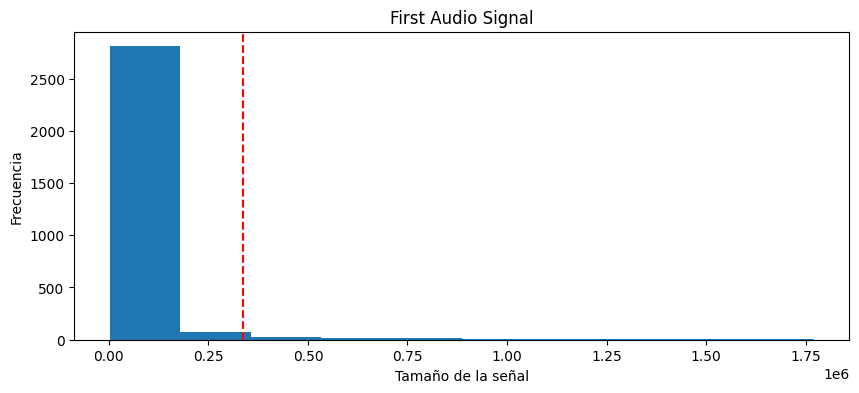

In [5]:
plt.figure(figsize=(10, 4))
plt.hist(tamaños)
plt.axvline(x=np.mean(tamaños)+1.5*np.std(tamaños), color='r', linestyle='--')
plt.xlabel('Tamaño de la señal')
plt.ylabel('Frecuencia')
plt.title('First Audio Signal')

plt.show()

In [6]:
def pad_audio(audio, target_length):
    if len(audio) > target_length:
        audio = audio[:target_length]
    elif len(audio) < target_length:
        padding = np.fft.fft(audio)
        audio = np.fft.ifft(padding,target_length)
    return audio.astype(np.float32)
target_audio_length = int(np.mean(tamaños)+1.5*np.std(tamaños))
X = [pad_audio(audio, target_audio_length) for audio in X]

/tmp/ipykernel_19/2624949803.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  return audio.astype(np.float32)


In [7]:
# Concatenate all audio data into a numpy array
audio_matrix = np.vstack(X)

print("Shape of the concatenated audio matrix:", audio_matrix.shape)
print("Shape of the labels array:", labels.shape)

Shape of the concatenated audio matrix: (2976, 337926)
Shape of the labels array: (2976,)


In [8]:
np.unique(labels)

array([0, 1])

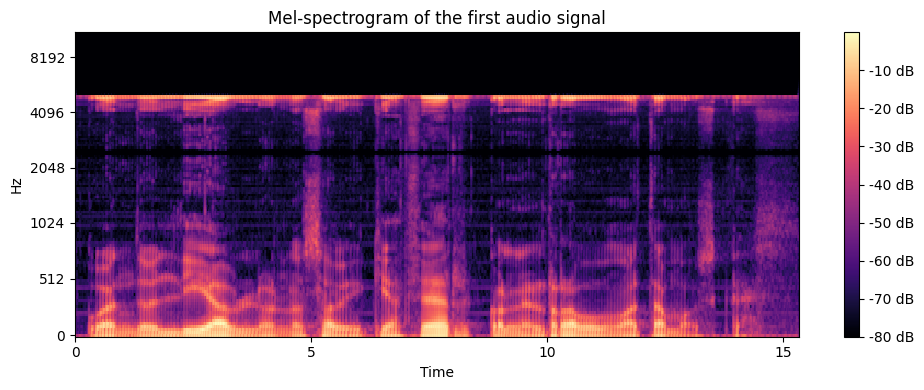

In [9]:
def create_melspectrogram(audio, sr=22050, n_fft=2048, hop_length=512, n_mels=128):
  """Generates a Mel spectrogram from an audio signal."""
  mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
  mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
  return mel_spectrogram_db

melspectrograms = [create_melspectrogram(audio) for audio in audio_matrix]


# Plot the first melspectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(melspectrograms[0], sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-spectrogram of the first audio signal')
plt.tight_layout()
plt.show()

In [10]:
X = np.array(melspectrograms)
y = labels

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2976, 128, 661)
Shape of y: (2976,)


In [11]:
import tensorflow as tf
from tensorflow import keras
import keras_hub
from keras_hub.layers import TransformerEncoder
from tensorflow.keras.layers import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# def visualize_attention(model, input_tensor):
#     """
#     Plots aggregated attention scores over time tokens (Attention Rollout).
#     """
#     # Get attention scores: shape (batch, heads, seq_len, seq_len)
#     scores = model.attention_extractor.predict(input_tensor[None, ...])[0] # take first batch
#     # Average over heads and layers if multiple
#     print(scores.shape)
#     rollout = scores @ np.eye(scores.shape[0])
#     importance = rollout.mean(axis=0)
#     # avg_scores = np.mean(scores, axis=0)  # (seq_len, seq_len)
#     # rollout = scores @ np.eye(avg_scores.shape[0])
#     # rollout = avg_scores @ rollout
#     # importance = np.mean(rollout, axis=0)  # (seq_len,)

#     print("importance:", importance[:10], "...")  
#     print("min, max:", importance.min(), importance.max())
#     print("sum:", importance.sum())

#     # Map back to original time by repeating
#     time_expanded = np.repeat(importance, repeats=int(input_tensor.shape[1] * input_tensor.shape[2] / importance.size))
#     plt.figure(figsize=(10,3))
#     plt.plot(time_expanded)
#     plt.title('Attention Rollout Importance')
#     plt.xlabel('Time')
#     plt.show()



def apply_grad_cam(model, input_tensor, class_index=None):
    """
    Generates and plots a Grad-CAM heatmap for the last conv layer.
    """
    def loss(output):
        return output[:, class_index]

    def model_modifier(m):
        # Return the last conv layer's output
        m.layers[-4].activation = tf.keras.activations.linear
        return m

    gradcam = Gradcam(model,
                      model_modifier=model_modifier,
                      clone=True)
    cam = gradcam(loss, input_tensor[np.newaxis, ...])
    heatmap = normalize(cam[0])

    plt.figure(figsize=(10,3))
    plt.imshow(heatmap, aspect='auto')
    plt.title('Grad-CAM Heatmap')
    plt.xlabel('Time-Frequency')
    plt.colorbar()
    plt.show()


def apply_lrp(model, input_tensor, class_index=None):
    """
    Computes and plots relevance scores using gradient-based saliency as proxy for LRP.
    """
    def loss(output):
        return output[:, class_index]

    saliency = Saliency(model)
    grads = saliency(loss, input_tensor[np.newaxis, ...])
    grads = normalize(grads[0])

    plt.figure(figsize=(10,3))
    plt.imshow(grads, aspect='auto')
    plt.title('Saliency Map (LRP Proxy)')
    plt.xlabel('Time-Frequency')
    plt.colorbar()
    plt.show()



# def create_audio_classification_model(input_shape, num_conv_layers, nb_classes):
#     """
#     Generates a TensorFlow neural network for audio classification with
#     convolutional layers, a TransformerEncoder, and dense layers.

#     Args:
#         input_shape (tuple): Shape of the input data (e.g., (height, width, channels)).
#         num_conv_layers (int): Number of convolutional layers to include.

#     Returns:
#         tf.keras.Model: The compiled Keras model.
#     """
#     input_tensor = Input(shape=input_shape)

#     x = input_tensor
#     for _ in range(num_conv_layers):
#         x = Conv2D(64, (3, 3), padding='same')(x)
#         x = BatchNormalization()(x)
#         x = Activation('elu')(x)
#         x = AveragePooling2D((3, 3))(x)

#     # Add the TransformerEncoder layer
#     # Reshape the output of the convolutional layers to be a sequence of tokens
#     batch_size, height, width, channels = x.shape
#     x = Reshape([height * width, channels])(x) # Reshape to (batch_size, sequence_length, embedding_dim)

#     transformer_layer = TransformerEncoder(
#         num_heads=2,  # Example value
#         intermediate_dim=64, # Example value
#         activation="relu",
#         dropout=0.1
#     )
#     x, attn_scores = transformer_layer(x, return_attention_scores= True)

#     # Flatten the output of the TransformerEncoder for the dense layers
#     x = Flatten()(x)

#     # Add dense layers for classification
#     x = Dense(128, activation='relu')(x)
#     x = Dropout(0.2)(x)
#     output_tensor = Dense(nb_classes, activation='sigmoid')(x) # Assuming binary classification

#     model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor)

#     model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC()])

#     model.attention_scores = attn_scores

#     return model

def create_audio_classification_model(input_shape, num_conv_layers, num_classes):
    """
    Builds a Keras model with convolutional blocks followed by a TransformerEncoder
    for audio classification.

    Args:
        input_shape (tuple): (time_steps, freq_bins, channels) of spectrogram input.
        num_conv_layers (int): Number of Conv2D + Pool blocks.
        num_classes (int): Number of output classes.

    Returns:
        tf.keras.Model: Compiled model with exposed attention scores.
    """
    inputs = Input(shape=input_shape)
    x = inputs

    # Convolutional feature extractor
    for _ in range(num_conv_layers):
        x = Conv2D(64, (3, 3), padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('elu')(x)
        x = AveragePooling2D((3, 3))(x)

    # Reshape for Transformer: (batch, sequence_length, embedding_dim)
    batch_size, height, width, channels = x.shape
    seq_len = height * width
    embed_dim = channels
    x = Reshape((seq_len, embed_dim))(x)

    # Transformer Encoder block (MultiHeadAttention with attention scores)
    attention_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=2,
        key_dim=embed_dim,
        dropout=0.1
        
    )
    attn_output, attn_scores = attention_layer(x, x, return_attention_scores=True)
    # Add & Norm
    x = tf.keras.layers.Add()([x, attn_output])
    x = tf.keras.layers.LayerNormalization()(x)

    # Feed-forward
    ffn = tf.keras.Sequential([
        Dense(64, activation='relu'),
        Dense(embed_dim)
    ])
    ffn_output = ffn(x)
    x = tf.keras.layers.Add()([x, ffn_output])
    x = tf.keras.layers.LayerNormalization()(x)
    # print(x.shape[1],x.shape[2],1)
    # x = tf.keras.layers.Reshape((x.shape[1],x.shape[2],1))
    
    # x = Conv2D(64, (3, 3), padding='same')(x)
    # x = BatchNormalization()(x)
    # x = Activation('elu')(x)
    # x = AveragePooling2D((3, 3))(x)
    # Flatten and classifier head
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', AUC()])
    # Expose attention scores for interpretability
    model.attention_scores = attn_scores
    return model


X = np.array(melspectrograms)
y = labels

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Reshape X to add a channel dimension if necessary
if len(X.shape) <= 3:
    X = np.expand_dims(X, axis=-1)

print(X.shape, y.shape)
oe = OneHotEncoder()
y = oe.fit_transform(y.reshape(-1, 1)).toarray()
input_shape_model = X.shape[1:] # Get shape excluding the number of samples

# Create the model
num_convolutional_layers = 2
nb_classes = 2
model = create_audio_classification_model(input_shape_model, num_convolutional_layers,nb_classes)

# Print the model summary
model.summary()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
# You can now train the model using your data X and y
# For example:
model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data = (X_test, y_test))
model.evaluate(X_test, y_test)



Shape of X: (2976, 128, 661)
Shape of y: (2976,)
(2976, 128, 661, 1) (2976,)


I0000 00:00:1748901592.883200      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748901592.883831      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 661, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 661, 64)   │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 661, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 661, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average_pooling2d         │ (None, 42, 220, 64)    │              0 │ activation[0][0]       │
│ (AveragePooling2D)        │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 42, 220, 64)    │         36,928 │ average_pooling2d[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 42, 220, 64)    │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 42, 220, 64)    │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average_pooling2d_1       │ (None, 14, 73, 64)     │              0 │ activation_1[0][0]     │
│ (AveragePooling2D)        │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1022, 64)       │              0 │ average_pooling2d_1[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ [(None, 1022, 64),     │         33,216 │ reshape[0][0],         │
│ (MultiHeadAttention)      │ (None, 2, 1022, 1022)] │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 1022, 64)       │              0 │ reshape[0][0],         │
│                           │                        │                │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 1022, 64)       │            128 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sequential (Sequential)   │ (None, 1022, 64)       │          8,320 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 1022, 64)       │              0 │ layer_normalization[0… │
│                           │                        │                │ sequential[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1

 Total params: 8,452,482 (32.24 MB)

...

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10


I0000 00:00:1748901603.514926      97 service.cc:148] XLA service 0x7b3220006db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748901603.515805      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748901603.515828      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748901604.217164      97 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1748901625.920633      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


19/19 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.5181 - auc: 0.5355 - loss: 6.7300 - val_accuracy: 0.5185 - val_auc: 0.5480 - val_loss: 1.3227
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 454ms/step - accuracy: 0.5581 - auc: 0.5645 - loss: 0.6789 - val_accuracy: 0.5201 - val_auc: 0.5160 - val_loss: 4.1343
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 462ms/step - accuracy: 0.5715 - auc: 0.5889 - loss: 0.6785 - val_accuracy: 0.5000 - val_auc: 0.4905 - val_loss: 1.4109
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 475ms/step - accuracy: 0.6025 - auc: 0.6536 - loss: 0.6465 - val_accuracy: 0.5268 - val_auc: 0.5063 - val_loss: 1.4463
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 482ms/step - accuracy: 0.6318 - auc: 0.6675 - loss: 0.6542 - val_accuracy: 0.5537 - val_auc: 0.5595 - val_loss: 1.2020
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 493ms/step - accuracy: 0.6341 - auc: 0.6771 - loss: 0.6395 - val_accuracy: 0.5436 - val_auc: 0.5355 - val_loss: 0.7453
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 501ms/step 

[0.6804805994033813, 0.5755033493041992, 0.6115715503692627]

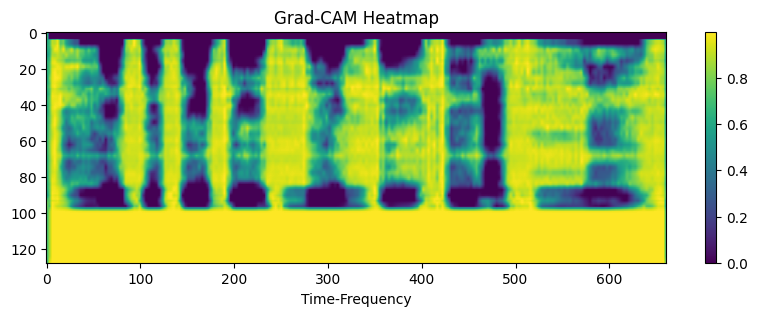

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 128, 661, 1))']
  warnings.warn(msg)


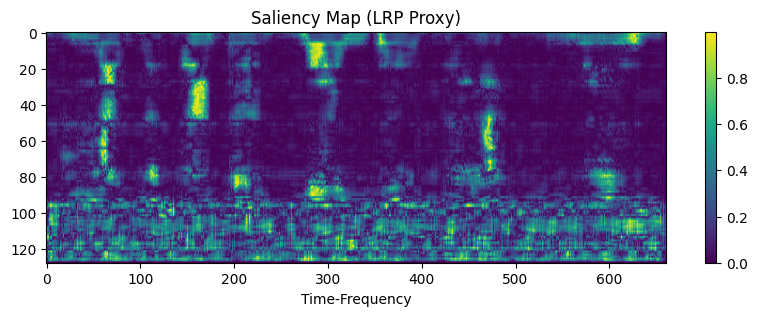

In [12]:
# def visualize_attention(model, input_tensor, num_pools=2, pool_size_time=3):
#     """
#     Muestra el Attention Rollout correctamente escalado al eje de tiempo real.
#     - num_pools: cuántas veces se aplicó AveragePooling2D((pool_size_time, pool_size_freq))
#     """
#     # 1) Extrae los scores reales vía extractor:
#     scores = model.attention_extractor.predict(input_tensor[None,...])[0]  # shape (heads, seq, seq) o (seq, seq)
#     # Si viene con 'heads' de más:
#     if scores.ndim == 3:
#         scores = scores.mean(axis=0)  # (seq, seq)

#     # 2) Attention Rollout
#     rollout = scores @ np.eye(scores.shape[0])
#     importance = rollout.mean(axis=0)  # vector de longitud seq


#     # 4) Expande y dibuja
#     time_expanded = np.repeat(importance, repeats=int(input_tensor.shape[1] * input_tensor.shape[2] / importance.size))
#     plt.figure(figsize=(10,3))     
#     plt.plot(time_expanded)
#     plt.title('Attention Rollout Importance')
#     plt.xlabel('Time Frame')
#     plt.ylabel('Importance')
#     plt.ylim(0, time_expanded.max()*1.1)
#     plt.show()

# # Expose real attention_scores as a Keras output
# attention_extractor = tf.keras.Model(
#     inputs = model.input,
#     outputs = model.attention_scores     # this was the symbolic tensor
# )
# # Attach it so you can access it later
# model.attention_extractor = attention_extractor

# visualize_attention(model, X_test[0])
apply_grad_cam(model, X_test[0], class_index=0)
apply_lrp(model, X_test[0], class_index=0)

In [13]:
from keras.callbacks import *

from tensorflow import keras
import keras_tuner
from keras_tuner import BayesianOptimization
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import gc
from keras import backend as K

K.clear_session()
gc.collect()

def build_model(hp):
    """Builds a Keras model for hyperparameter tuning."""
    input_shape = X_train.shape[1:]
    input_tensor = Input(shape=input_shape)

    x = input_tensor
    filters=hp.Int(f'conv_filters', min_value=16, max_value=64, step=16)
    act = hp.Choice(f'conv_activation', ['elu','gelu','tanh'])
    num_conv_layers = hp.Int('num_conv_layers', min_value=1, max_value=3, step=1)
    kernel_size = hp.Int('kernel_size', min_value=3, max_value=5, step=1)
    for i in range(num_conv_layers):
        x = Conv2D(
            filters = filters,
            kernel_size=(kernel_size, kernel_size),
            padding='same'
        )(x)
        x = BatchNormalization()(x)
        x = Activation(act)(x)
        x = AveragePooling2D((3, 3))(x)

    batch_size, height, width, channels = x.shape
    x = Reshape([height * width, channels])(x)

    # attention_layer = TransformerEncoder(
    #     num_heads=hp.Int('transformer_num_heads', min_value=2, max_value=4),
    #     intermediate_dim=hp.Int('transformer_intermediate_dim', min_value=64, max_value=256, step=64),
    #     activation="relu",
    #     dropout=hp.Float('transformer_dropout', min_value=0.1, max_value=0.5, step=0.1)
    # )

    # x, attn_scores = attention_layer(x, x, return_attention_scores=True)

    # x = Flatten()(x)

    # x = Dense(
    #     units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
    #     activation=hp.Choice(f'activation_transformer', ['elu','gelu','tanh'])
    # )(x)
    # x = Dropout(hp.Float('dense_dropout', min_value=0.1, max_value=0.5, step=0.1))(x)
    # output_tensor = Dense(nb_classes, activation='sigmoid')(x)

    # model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor)

    # model.compile(
    #     optimizer=keras.optimizers.Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
    #     loss='binary_crossentropy',
    #     metrics=['accuracy', keras.metrics.AUC()]
    # )
    # model.attention_scores = attn_scores
    embed_dim = hp.Int('transformer_intermediate_dim', min_value=64, max_value=128, step=64)
    # Transformer Encoder block (MultiHeadAttention with attention scores)
    attention_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=hp.Int('transformer_num_heads', min_value=1, max_value=4),
        key_dim=embed_dim,
        dropout=hp.Float('transformer_dropout', min_value=0.1, max_value=0.3, step=0.1)
    )
    attn_output, attn_scores = attention_layer(x, x, return_attention_scores=True)
    # Add & Norm
    x = tf.keras.layers.Add()([x, attn_output])
    x = tf.keras.layers.LayerNormalization()(x)

    # Feed-forward
    ffn = tf.keras.Sequential([
        Dense(hp.Int('first_ffn', min_value=64, max_value=256, step=64), activation='relu'),
        Dense(x.shape[-1])
    ])
    ffn_output = ffn(x)
    x = tf.keras.layers.Add()([x, ffn_output])
    x = tf.keras.layers.LayerNormalization()(x)

    # Flatten and classifier head
    x = Flatten()(x)
    x = Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation=hp.Choice(f'activation_transformer', ['elu','gelu','tanh'])
    )(x)
    x = Dropout(hp.Float('dense_dropout', min_value=0.1, max_value=0.3, step=0.1))(x)
    output_tensor = Dense(nb_classes, activation='softmax')(x)

    model = Model(input_tensor, output_tensor)
    model.compile(optimizer='adam',
                  loss=keras.losses.categorical_crossentropy,
                  metrics=['accuracy', AUC()])
    # Expose attention scores for interpretability
    model.attention_scores = attn_scores
    return model

tuner = BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='my_dir_ini',
    project_name='audio_classification'
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.001)
checkpoint_filepath = '/tmp/ckpt/checkpoint.model.keras'
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)
# tuner.search(X_train, y_train,batch_size=32, epochs=10, validation_data=(X_test, y_test)) 

# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# print(best_hps)
# print(f"""
# The optimal number of convolutional layers is {best_hps.get('num_conv_layers')}.
# The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
# ... (print other optimal hyperparameters)
# """)


def cross_validate_model(results, n_splits=5):
    """
    Performs cross-validation on the model with the given hyperparameters.

    Args:
        dataframe (pd.DataFrame): DataFrame containing the data (features and labels).
        best_hyperparameters (HyperParameters): The optimal hyperparameters from Keras Tuner.
        n_splits (int): Number of folds for cross-validation.

    Returns:
        tuple: A tuple containing a list of dictionaries with fold results and a DataFrame
               with mean and standard deviation of metrics.
    """
    X = np.array(melspectrograms)
    y = labels
    oe = OneHotEncoder()
    y = oe.fit_transform(y.reshape(-1, 1)).toarray()
    X = np.expand_dims(X, axis=-1)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    
    accuracy_scores = []
    f1_scores = []
    auc_scores = []
    precision_scores = []
    recall_scores = []
    best_hps = []
    modelos = []

    for fold, (train_index, val_index) in enumerate(kf.split(X, np.argmax(y, axis=1))): # Stratify on the original integer labels
        print(f"--- Fold {fold+1}/{n_splits} ---")
        K.clear_session()
        gc.collect()
        X_train_fold, X_val_fold = X[train_index], X[val_index]
        y_train_fold, y_val_fold = y[train_index], y[val_index]
        
        if fold > 3:
            
            tuner = BayesianOptimization(
                build_model,
                objective='val_accuracy',
                max_trials=15,
                executions_per_trial=1,
                directory='my_dir2_2',
                project_name=f'audio_classification_fold_{fold+1}'
            )
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                          patience=5, min_lr=0.001)
            checkpoint_filepath = f'/tmp/ckpt/checkpoint{fold+1}.model.keras'
            model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_filepath,
                monitor='val_accuracy',
                mode='max',
                save_best_only=True)
            
            tuner.search(X_train_fold, y_train_fold, epochs=100, validation_data=(X_val_fold, y_val_fold), 
                         callbacks=[reduce_lr, model_checkpoint_callback], batch_size=32) 
            best_hps.append(tuner.get_best_hyperparameters(num_trials=1)[0].values)
            
            # Build the model with the best hyperparameters
            model = tuner.get_best_models(num_models=1)[0]
            
            # # Train the model
            # model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, verbose=0, validation_data=(X_val_fold,y_val_fold),
            #           callbacks=[reduce_lr, model_checkpoint_callback]) # Reduced epochs for faster CV
            
            model.save(f'model_fold_{fold+1}_NeuroVoz.h5')
        else:
                
            model = tf.keras.models.load_model(f'/kaggle/input/optimizados_2/tensorflow2/default/1/model_fold_{fold+1}_NeuroVoz.h5', compile=False)
            model.compile(
                          optimizer=keras.optimizers.Adam(0.01),
                          loss='binary_crossentropy',
                          metrics=['accuracy', keras.metrics.AUC()]
                      )
        # Evaluate the model on the validation fold
        y_pred_proba = model.predict(X_val_fold)
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Calculate metrics
        scores = model.evaluate(X_val_fold,y_val_fold)
        accuracy = scores[-2]
        auc = scores[-1]
        f1 = f1_score(y_val_fold, y_pred, average='macro') # Use macro average for multi-class
        precision = precision_score(y_val_fold, y_pred, average='macro')
        recall = recall_score(y_val_fold, y_pred, average='macro')

        accuracy_scores.append(accuracy)
        f1_scores.append(f1)
        auc_scores.append(auc)
        precision_scores.append(precision)
        recall_scores.append(recall)
        modelos.append(model)

        print(f"Fold {fold+1} - Accuracy: {accuracy:.4f}, F1-score: {f1:.4f}")

    

    indice = accuracy_scores.index(max(accuracy_scores))
    model = modelos[indice]
    
    # Calculate mean and standard deviation of metrics
    mean_accuracy = np.mean(accuracy_scores)
    std_accuracy = np.std(accuracy_scores)
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)
    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)

    resultados = {
        'Mean Acc': [mean_accuracy],
        'Std Acc': [std_accuracy],
        'Mean f1-score': [mean_f1],
        'Std f1-score': [std_f1],
        'Mean AUC': [mean_auc],
        'Std AUC': [std_auc], 
        'Precision': [np.mean(precision_scores)],
        'Recall':[np.mean(recall_scores)]
    
    }

    results = pd.concat([results, pd.DataFrame(resultados)], ignore_index=True)
    hyperparameters = pd.DataFrame(best_hps)
    # hyperparameters['Accuracy'] = accuracy_scores
    
    return results, hyperparameters, model


df_combined = pd.DataFrame(columns=['Mean Acc', 'Std Acc','Mean f1-score','Std f1-score','Mean AUC','Std AUC',  'Precision', 'Recall'])


# Perform cross-validation
fold_results, best_hyperparameters, model = cross_validate_model(df_combined,  n_splits=5)


Trial 15 Complete [00h 00m 11s]

Best val_accuracy So Far: 0.7983193397521973
Total elapsed time: 02h 36m 39s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.7850 - auc: 0.8314 - loss: 1.3546
Fold 5 - Accuracy: 0.7983, F1-score: 0.7982


/tmp/ipykernel_19/2835214154.py:251: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame(resultados)], ignore_index=True)


In [14]:
print("\n--- Cross-Validation Fold Results ---")
print(fold_results)

print("\n--- Final Results (Hyperparameters and Metrics Summary) ---")
print(best_hyperparameters)


--- Cross-Validation Fold Results ---
   Mean Acc   Std Acc  Mean f1-score  Std f1-score  Mean AUC   Std AUC  \
0   0.77251  0.016121       0.771604      0.016581  0.818788  0.018256   

   Precision    Recall  
0   0.775227  0.771903  

--- Final Results (Hyperparameters and Metrics Summary) ---
   conv_filters conv_activation  num_conv_layers  kernel_size  \
0            16            gelu                3            4   

   transformer_intermediate_dim  transformer_num_heads  transformer_dropout  \
0                            64                      3                  0.1   

   first_ffn  dense_units activation_transformer  dense_dropout  
0        256           96                    elu            0.1  


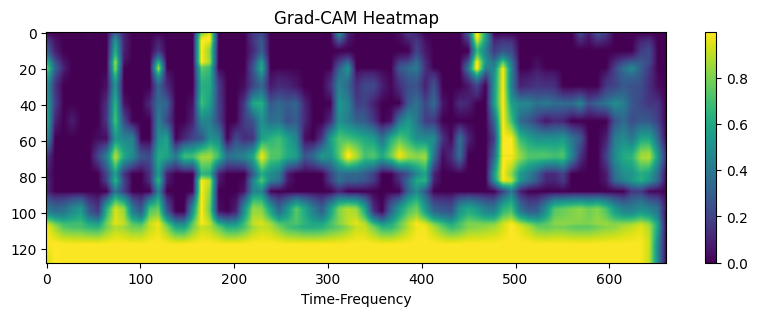

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 128, 661, 1))']
  warnings.warn(msg)


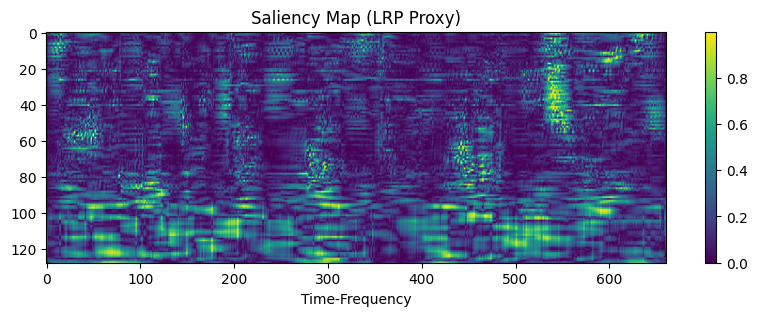

In [15]:
img_grad_cam= apply_grad_cam(model, X_test[0], class_index=0)
img_lrp= apply_lrp(model, X_test[0], class_index=0)

# audio = librosa.feature.inverse.mel_to_audio(img_grad_cam)
# audio2 = librosa.feature.inverse.mel_to_audio(img_lrp)

In [16]:
from IPython.display import Audio

# y: array de la señal de audio (float32 o float64)
# sr: frecuencia de muestreo en Hz

# Crea un widget de audio embebido en el notebook
# Audio(data=audio, rate=22050)


In [17]:
# Audio(data=audio2, rate=22050)

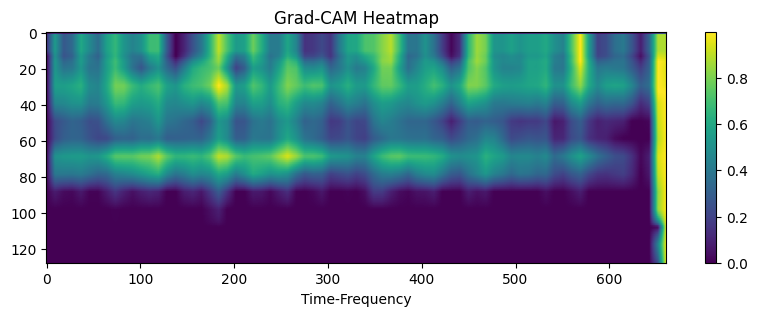

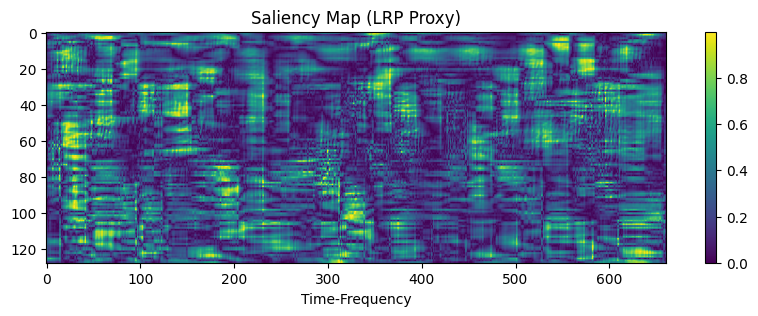

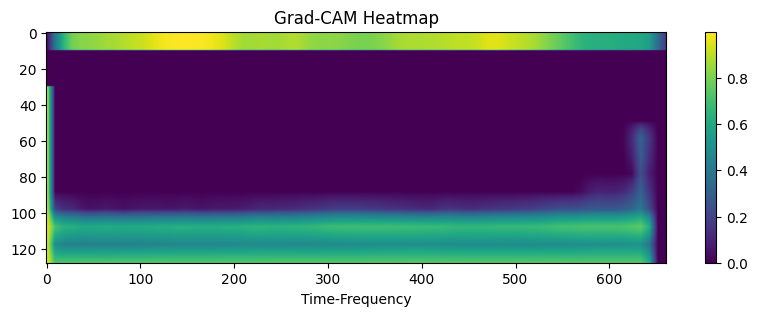

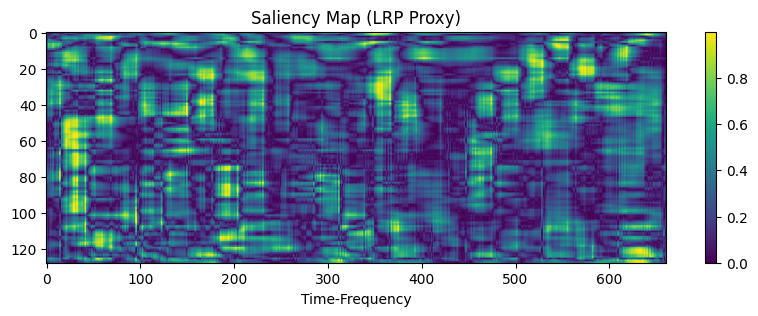

In [18]:
X_hc = np.mean(X[:42],axis=0)
X_pd = np.mean(X[42:],axis=0)

for clase, x in enumerate([X_hc,X_pd]):
    img_grad_cam= apply_grad_cam(model, x, class_index=clase)
    img_lrp= apply_lrp(model, x, class_index=clase)
    
    # audio = librosa.feature.inverse.mel_to_audio(img_grad_cam)
    # audio2 = librosa.feature.inverse.mel_to_audio(img_lrp)
    # if clase == 0:
    #     valor = 'Health Control'
    # else:
    #     valor = 'Parkinson Disease'
    # plt.figure(figsize=(10,3))     
    # plt.plot(audio)
    # plt.title(f'Audio recreated from gradCAM for {valor} pacients')
    # plt.xlabel('Time Frame')
    # plt.ylabel('Voltage')
    # plt.show()
    
    # plt.figure(figsize=(10,3))     
    # plt.plot(audio2)
    # plt.title(f'Audio recreated from lrp for {valor} pacients')
    # plt.xlabel('Time Frame')
    # plt.ylabel('Voltage')
    # plt.show()

In [19]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X)
confusion_matrix(np.argmax(y,axis=-1),np.argmax(y_pred,axis=-1))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


array([[1454,   55],
       [  65, 1402]])

In [20]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 661, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 661, 16)   │            272 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 661, 16)   │             64 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 661, 16)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average_pooling2d         │ (None, 42, 220, 16)    │              0 │ activation[0][0]       │
│ (AveragePooling2D)        │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 42, 220, 16)    │          4,112 │ average_pooling2d[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 42, 220, 16)    │             64 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 42, 220, 16)    │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average_pooling2d_1       │ (None, 14, 73, 16)     │              0 │ activation_1[0][0]     │
│ (AveragePooling2D)        │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 14, 73, 16)     │          4,112 │ average_pooling2d_1[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 14, 73, 16)     │             64 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 14, 73, 16)     │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average_pooling2d_2       │ (None, 4, 24, 16)      │              0 │ activation_2[0][0]     │
│ (AveragePooling2D)        │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 96, 16)         │              0 │ average_pooling2d_2[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ [(None, 96, 16),       │         12,880 │ reshape[0][0],         │
│ (MultiHeadAttention)      │ (None, 3, 96, 96)]     │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 96, 16)         │              0 │ reshape[0][0],         │
│                      

 Total params: 177,842 (694.70 KB)

 Trainable params: 177,746 (694.32 KB)

 Non-trainable params: 96 (384.00 B)

In [21]:
def plot_attention_scores(att_scores: np.ndarray,
                          tokens_q: list = None,
                          tokens_k: list = None,
                          head: int = 0,
                          figsize: tuple = (8, 8),
                          cmap: str = 'viridis') -> None:
    """
    Visualiza los puntajes de atención de una sola cabeza de atención,
    junto con el promedio de atención por clave y por consulta.

    Parámetros
    ----------
    att_scores : np.ndarray
        Tensor de forma (batch_size, num_heads, seq_len_q, seq_len_k).
    tokens_q : list, opcional
        Etiquetas para los tokens de consulta (eje y).
    tokens_k : list, opcional
        Etiquetas para los tokens de clave/valor (eje x).
    head : int, opcional
        Índice de la cabeza de atención.
    figsize : tuple, opcional
        Tamaño de la figura.
    cmap : str, opcional
        Mapa de colores para la visualización.
    """
    scores = att_scores[head]  # (seq_len_q, seq_len_k)
    att_mean_q = np.mean(scores, axis=1)  # Promedio sobre columnas (consulta)
    att_mean_k = np.mean(scores, axis=0)  # Promedio sobre filas (clave)

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 6], height_ratios=[1, 6],
                           wspace=0.05, hspace=0.05)

    # Gráfico superior: promedio por clave
    ax_top = plt.subplot(gs[0, 1])
    ax_top.bar(np.arange(scores.shape[1]), att_mean_k, color='gray')
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_xlim([0, scores.shape[1]])

    # Gráfico lateral izquierdo: promedio por consulta
    ax_left = plt.subplot(gs[1, 0])
    ax_left.barh(np.arange(scores.shape[0]), att_mean_q, color='gray')
    ax_left.set_xticks([])
    ax_left.set_yticks([])
    ax_left.set_ylim([scores.shape[0] - 0.5, -0.5])  # invertir para alinear

    # Gráfico principal: mapa de atención
    ax_main = plt.subplot(gs[1, 1])
    im = ax_main.imshow(scores, aspect='auto', cmap=cmap)
    plt.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)

    if tokens_q is not None:
        ax_main.set_yticks(np.arange(len(tokens_q)))
        ax_main.set_yticklabels(tokens_q)
    if tokens_k is not None:
        ax_main.set_xticks(np.arange(len(tokens_k)))
        ax_main.set_xticklabels(tokens_k, rotation=90)

    ax_main.set_xlabel("Tokens de clave / valor")
    ax_main.set_ylabel("Tokens de consulta")
    ax_main.set_title(f"Puntajes de atención — Cabeza {head}")

    plt.tight_layout()
    plt.show()

# Expose real attention_scores as a Keras output
attention_extractor = tf.keras.Model(
    inputs = model.input,
    outputs = model.attention_scores     # this was the symbolic tensor
)
# Attach it so you can access it later
model.attention_extractor = attention_extractor

scores = model.attention_extractor.predict(X_hc[None,...])[0]
# scores = np.sum(model.attention_extractor.predict(X_hc[None,...])[0],axis=0)
print(scores.shape)
for head in range(2):
    plot_attention_scores(scores, head=head)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
(3, 96, 96)


NameError: name 'gridspec' is not defined

<Figure size 800x800 with 0 Axes>